# Exploring the Adult Dataset with SHAP

Adapted from: Molnar, C. (2023). Interpreting machine learning models with SHAP: A Guide with Python Examples and Theory on Shapley Values.

In [ ]:
import shap
from sklearn.model_selection import train_test_split

In [ ]:
X, y= shap.datasets.adult()

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=1)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np

In [ ]:
#Define cats and nums

cats = ['Workclass', 'Marital Status', 'Occupation', 'Relationship', 'Race', 'Sex', 'Country']
nums = ['Age', 'Education-Num', 'Capital Gain', 'Capital Loss', 'Hours per week']

In [ ]:
#Define the column transformer

preprocessor = ColumnTransformer(
    transformers =[
        ('cat', OneHotEncoder(), cats),
        ('num', StandardScaler(), nums)
    ]
)

In [ ]:
# Define the pipeline

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=10000))
])

In [ ]:
# Fit the pipeline

model.fit(X_train, y_train)

X_sub = shap.sample(X_train, 100)

ex = shap.Explainer(model.predict_proba, X_sub)
shap_values = ex(X_test.iloc[0:100])

PermutationExplainer explainer: 101it [00:16,  2.70it/s]                         


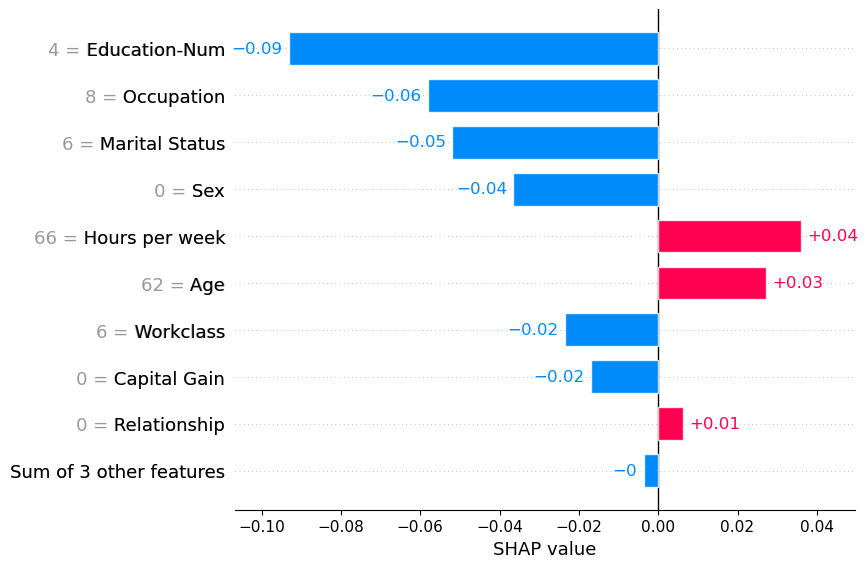

In [ ]:
# bar plot

class_index = 1
data_index = 0

shap.plots.bar(shap_values[data_index,:,class_index])

In [ ]:
# force plot

shap.initjs()

shap.plots.force(shap_values[data_index,:,class_index])

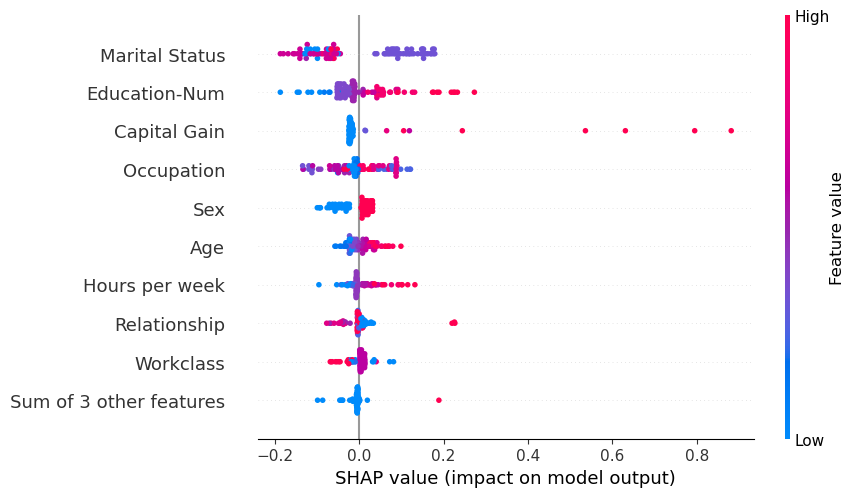

In [ ]:
shap.plots.beeswarm(shap_values[:,:,class_index])